In [109]:
# loading the libraries
import pandas as pd

# Setup plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [111]:
# loading the data
data = pd.read_csv('poetry_study_2026-03-24.csv')

# dropping irrelevant columns
cols_to_drop = [
    'emotional_impact_answer',
    'originality_answer',
    'like_answer',
    'human_authorship_answer',

    # time fields
    'timestamp',
    'completedAt'
]

data = data.drop(columns=cols_to_drop)

data.sample(n=10)

,sessionId,familiarity,comparisonId,comparison_type,theme,poemA_id,poemB_id,original_condition_A,original_condition_B,displayed_left_poem_id,...,stronger_overall_selected_poem_id,stronger_overall_selected_condition,emotional_impact_selected_poem_id,emotional_impact_selected_condition,originality_selected_poem_id,originality_selected_condition,like_selected_poem_id,like_selected_condition,human_authorship_selected_poem_id,human_authorship_selected_condition
66,sess_rzepk1a9_1774289816769,very_familiar,comp-37,Baseline_vs_Persona,Hope,Hope-Baseline-2,Hope-Persona-2,Baseline,Persona,Hope-Baseline-2,...,Hope-Persona-2,Persona,Hope-Persona-2,Persona,Hope-Persona-2,Persona,Hope-Persona-2,Persona,BOTH,BOTH
76,sess_s9g2eue4_1774187671674,very_familiar,comp-19,Baseline_vs_Guideline,Grief,Grief-Baseline-4,Grief-Guideline-4,Baseline,Guideline,Grief-Guideline-4,...,Grief-Guideline-4,Guideline,Grief-Guideline-4,Guideline,Grief-Baseline-4,Baseline,BOTH,BOTH,Grief-Baseline-4,Baseline
34,sess_etdwuxw9_1773688930509,very_familiar,comp-25,Baseline_vs_Persona,Grief,Grief-Baseline-5,Grief-Persona-5,Baseline,Persona,Grief-Baseline-5,...,NaN,NaN,Grief-Baseline-5,Baseline,BOTH,BOTH,Grief-Baseline-5,Baseline,BOTH,BOTH
47,sess_mwagss7u_1773732343303,somewhat_familiar,comp-22,Baseline_vs_Persona,Grief,Grief-Baseline-2,Grief-Persona-2,Baseline,Persona,Grief-Persona-2,...,Grief-Persona-2,Persona,Grief-Baseline-2,Baseline,Grief-Baseline-2,Baseline,BOTH,BOTH,Grief-Baseline-2,Baseline
30,sess_etdwuxw9_1773688930509,very_familiar,comp-03,Baseline_vs_Guideline,Longing,Longing-Baseline-3,Longing-Guideline-3,Baseline,Guideline,Longing-Baseline-3,...,Longing-Baseline-3,Baseline,Longing-Guideline-3,Guideline,Longing-Guideline-3,Guideline,Longing-Guideline-3,Guideline,Longing-Baseline-3,Baseline
80,sess_s9g2eue4_1774187671674,very_familiar,comp-42,Guideline_vs_Persona,Hope,Hope-Guideline-2,Hope-Persona-2,Guideline,Persona,Hope-Persona-2,...,Hope-Guideline-2,Guideline,Hope-Persona-2,Persona,Hope-Guideline-2,Guideline,Hope-Guideline-2,Guideline,Hope-Guideline-2,Guideline
27,sess_etdwuxw9_1773688930509,very_familiar,comp-21,Baseline_vs_Persona,Grief,Grief-Baseline-1,Grief-Persona-1,Baseline,Persona,Grief-Persona-1,...,Grief-Baseline-1,Baseline,Grief-Baseline-1,Baseline,Grief-Baseline-1,Baseline,Grief-Baseline-1,Baseline,Grief-Baseline-1,Baseline
18,sess_9w06nzxm_1773738754404,not_very_familiar,comp-27,Guideline_vs_Persona,Grief,Grief-Guideline-2,Grief-Persona-2,Guideline,Persona,Grief-Persona-2,...,Grief-Guideline-2,Guideline,Grief-Guideline-2,Guideline,Grief-Guideline-2,Guideline,Grief-Persona-2,Persona,Grief-Persona-2,Persona
35,sess_etdwuxw9_1773688930509,very_familiar,comp-07,Baseline_vs_Persona,Longing,Longing-Baseline-2,Longing-Persona-2,Baseline,Persona,Longing-Baseline-2,...,NaN,NaN,BOTH,BOTH,BOTH,BOTH,BOTH,BOTH,BOTH,BOTH
57,sess_n5baf3fo_1773740926289,very_familiar,comp-25,Baseline_vs_Persona,Grief,Grief-Baseline-5,Grief-Persona-5,Baseline,Persona,Grief-Baseline-5,...,Grief-Persona-5,Persona,Grief-Baseline-5,Baseline,Grief-Baseline-5,Baseline,Grief-Baseline-5,Baseline,Grief-Baseline-5,Baseline


In [113]:
# data['stronger_overall_answer'].unique()

In [114]:
# checking missing values
data.isna().sum()

sessionId                               0
familiarity                             0
comparisonId                            0
comparison_type                         0
theme                                   0
poemA_id                                0
poemB_id                                0
original_condition_A                    0
original_condition_B                    0
displayed_left_poem_id                  0
displayed_right_poem_id                 0
displayed_left_condition                0
displayed_right_condition               0
stronger_overall_answer                 0
stronger_overall_selected_poem_id      15
stronger_overall_selected_condition    15
emotional_impact_selected_poem_id       0
emotional_impact_selected_condition     0
originality_selected_poem_id            0
originality_selected_condition          0
like_selected_poem_id                   0
like_selected_condition                 0
human_authorship_selected_poem_id       0
human_authorship_selected_conditio

In [115]:
# We simply fill NaN with 'TIE' to match the 'BOTH'/'NEITHER' pattern.
data['stronger_overall_selected_condition'] = data['stronger_overall_selected_condition'].fillna('TIE')
data['stronger_overall_selected_poem_id'] = data['stronger_overall_selected_poem_id'].fillna('TIE')

# INSIGHTS FROM RESULTS

## Participant Overview & Descriptives


In [117]:
# Set aesthetic style
sns.set_theme(style="whitegrid", context="talk")
palette = {'Baseline': '#95a5a6', 'Guideline': '#2ecc71', 'Persona': '#e74c3c', 'TIE': '#bdc3c7', 'BOTH': '#34495e', 'NEITHER': '#95a5a6', 'NOT_SURE': '#ecf0f1'}

In [118]:
# Participant Overview
unique_participants = data['sessionId'].nunique()
total_responses = len(data)

print(f"Total Unique Participants: {unique_participants}")
print(f"Total Responses: {total_responses}")
print(f"Responses per Participant (Sanity Check): {total_responses / unique_participants:.1f} (Expected: 9.0)\n")

print("--- Familiarity Distribution ---")
fam_counts = data.drop_duplicates('sessionId')['familiarity'].value_counts()
fam_pct = data.drop_duplicates('sessionId')['familiarity'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'
display(pd.DataFrame({'Count': fam_counts, 'Percentage': fam_pct}))

print("\n--- Comparisons per Condition Pair ---")
pair_counts = data['comparison_type'].value_counts()
display(pair_counts)

print(f"\nTotal 'TIE' Responses (Stronger Overall): {(data['stronger_overall_selected_condition'] == 'TIE').sum()}")


Total Unique Participants: 9
Total Responses: 81
Responses per Participant (Sanity Check): 9.0 (Expected: 9.0)

--- Familiarity Distribution ---


,Count,Percentage
familiarity,,
very_familiar,6,66.7%
somewhat_familiar,2,22.2%
not_very_familiar,1,11.1%



--- Comparisons per Condition Pair ---


comparison_type
Guideline_vs_Persona     32
Baseline_vs_Persona      26
Baseline_vs_Guideline    23
Name: count, dtype: int64


Total 'TIE' Responses (Stronger Overall): 15


## Overall Win Rates (Main Effects)


In [119]:
# Overall Win Rates
# Count how many times each condition won across all evaluations
metrics = ['stronger_overall', 'emotional_impact', 'originality', 'like']

for metric in metrics:
    col = f"{metric}_selected_condition"
    wins = data[data[col].isin(['Baseline', 'Guideline', 'Persona'])][col].value_counts()
    print(f"\n--- {metric.replace('_', ' ').title()} Wins ---")
    print(wins)


--- Stronger Overall Wins ---
stronger_overall_selected_condition
Guideline    25
Baseline     23
Persona      18
Name: count, dtype: int64

--- Emotional Impact Wins ---
emotional_impact_selected_condition
Guideline    34
Baseline     21
Persona      10
Name: count, dtype: int64

--- Originality Wins ---
originality_selected_condition
Guideline    24
Baseline     22
Persona      13
Name: count, dtype: int64

--- Like Wins ---
like_selected_condition
Guideline    26
Baseline     25
Persona      14
Name: count, dtype: int64


### Overall Win Rates
A grouped bar chart showing absolute wins across all 4 categories.

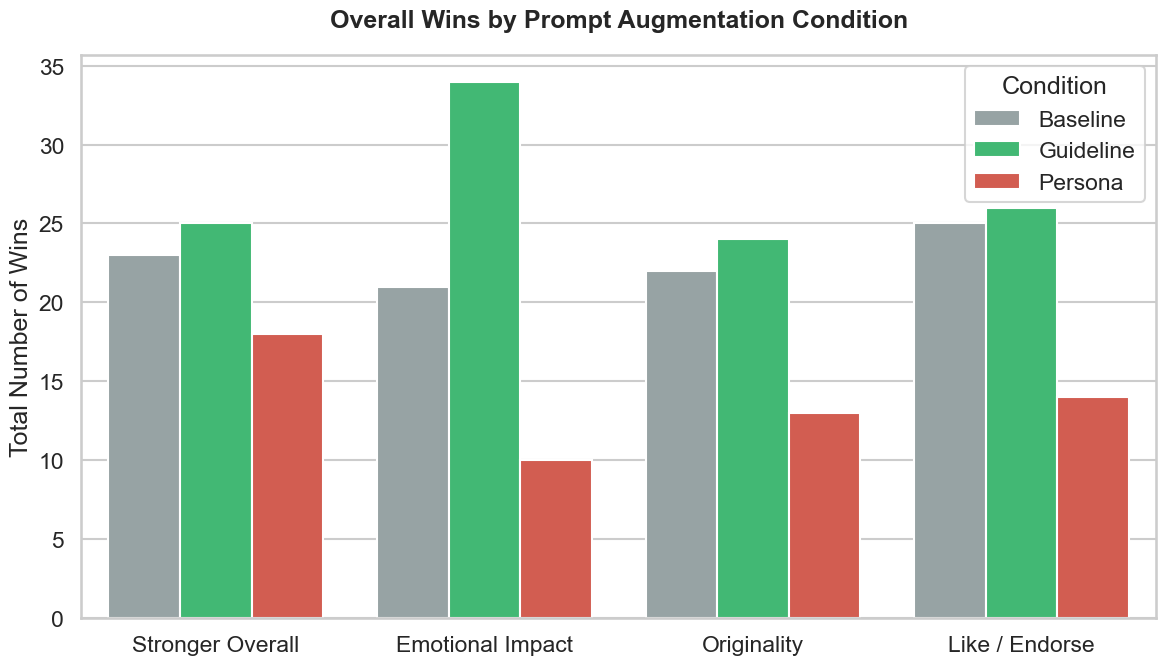

In [120]:
# Overall Win Rates Bar Chart
fig, ax = plt.subplots(figsize=(12, 7))

win_data = []
categories = ['stronger_overall', 'emotional_impact', 'originality', 'like']
labels = ['Stronger Overall', 'Emotional Impact', 'Originality', 'Like / Endorse']

for cat, label in zip(categories, labels):
    col = f"{cat}_selected_condition"
    counts = data[data[col].isin(['Baseline', 'Guideline', 'Persona'])][col].value_counts()
    for cond in ['Baseline', 'Guideline', 'Persona']:
        win_data.append({'Category': label, 'Condition': cond, 'Wins': counts.get(cond, 0)})

df_wins = pd.DataFrame(win_data)

sns.barplot(data=df_wins, x='Category', y='Wins', hue='Condition', palette=palette, ax=ax)
ax.set_title('Overall Wins by Prompt Augmentation Condition', pad=20, fontweight='bold')
ax.set_ylabel('Total Number of Wins')
ax.set_xlabel('')
plt.legend(title='Condition')
plt.tight_layout()
plt.show()

## Head-to-Head Statistics (Pairwise)


In [121]:
# Pairwise comparisons: Calculate Win % and Significance for each pair
from scipy.stats import binomtest

comparisons = ['Baseline_vs_Guideline', 'Baseline_vs_Persona', 'Guideline_vs_Persona']
metrics = ['stronger_overall', 'emotional_impact', 'originality', 'like']

for comp in comparisons:
    print(f"\n{'='*50}\n{comp}\n{'='*50}")
    subset = data[data['comparison_type'] == comp]
    cond_A, cond_B = comp.split('_vs_')
    
    for metric in metrics:
        col = f"{metric}_selected_condition"
        
        # Count explicit wins for A and B (excluding Ties/Both/Neither)
        wins_A = (subset[col] == cond_A).sum()
        wins_B = (subset[col] == cond_B).sum()
        total_decisions = wins_A + wins_B
        
        if total_decisions > 0:
            pct_A = (wins_A / total_decisions) * 100
            pct_B = (wins_B / total_decisions) * 100
            
            # Simple binomial test for significance (Null Hypothesis: p=0.5)
            p_val = binomtest(wins_A, total_decisions, p=0.5, alternative='two-sided').pvalue
            sig = '*' if p_val < 0.05 else ''
            
            print(f"{metric:>20}: {cond_A} ({pct_A:.1f}%) vs {cond_B} ({pct_B:.1f}%) | p={p_val:.3f} {sig}")



Baseline_vs_Guideline
    stronger_overall: Baseline (55.0%) vs Guideline (45.0%) | p=0.824 
    emotional_impact: Baseline (33.3%) vs Guideline (66.7%) | p=0.189 
         originality: Baseline (58.8%) vs Guideline (41.2%) | p=0.629 
                like: Baseline (57.9%) vs Guideline (42.1%) | p=0.648 

Baseline_vs_Persona
    stronger_overall: Baseline (60.0%) vs Persona (40.0%) | p=0.503 
    emotional_impact: Baseline (73.7%) vs Persona (26.3%) | p=0.064 
         originality: Baseline (70.6%) vs Persona (29.4%) | p=0.143 
                like: Baseline (73.7%) vs Persona (26.3%) | p=0.064 

Guideline_vs_Persona
    stronger_overall: Guideline (61.5%) vs Persona (38.5%) | p=0.327 
    emotional_impact: Guideline (80.0%) vs Persona (20.0%) | p=0.004 *
         originality: Guideline (68.0%) vs Persona (32.0%) | p=0.108 
                like: Guideline (66.7%) vs Persona (33.3%) | p=0.122 


## Thematic Interactions


--- Win Distribution per Condition by Theme (Raw Counts) ---


stronger_overall_selected_condition,Baseline,Guideline,Persona
theme,,,
Grief,6,9,5
Hope,11,7,5
Longing,6,9,8



--- Win Percentage Distribution by Theme (%) ---


stronger_overall_selected_condition,Baseline,Guideline,Persona
theme,,,
Grief,30.0%,45.0%,25.0%
Hope,47.8%,30.4%,21.7%
Longing,26.1%,39.1%,34.8%



Chi-Square Test of Independence for Theme vs Prompt Strategy: p=0.535 
-> Result: While there are variances, prompt strategy effectiveness does not have a statistically significant dependency on the theme in this sample size.


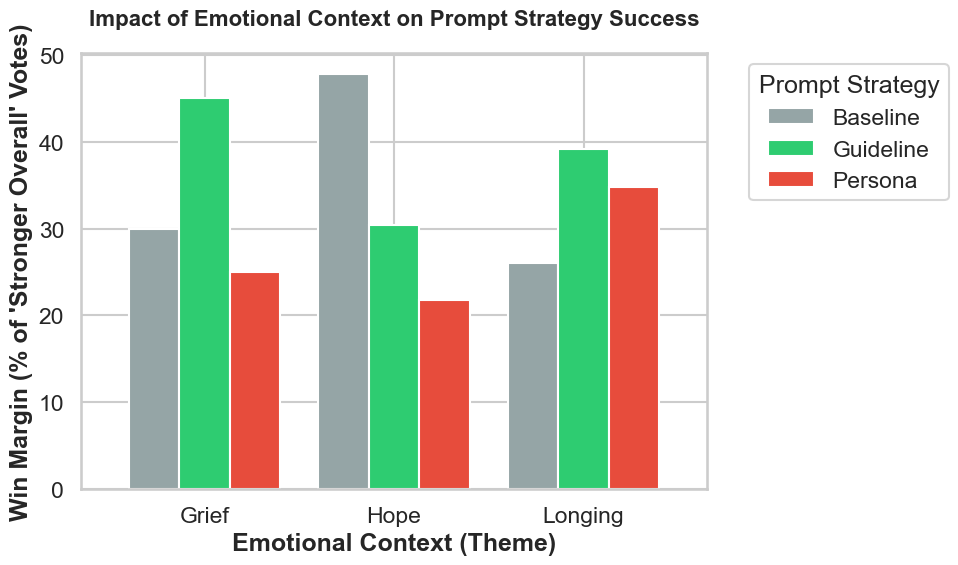

In [122]:
# 4. Thematic Interactions (Publishable Angle)
# Do specific prompt strategies perform better for specific emotional contexts?
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# We will use the aesthetic palette established in Step 6 if it exists, otherwise define a fallback
palette = {'Baseline': '#95a5a6', 'Guideline': '#2ecc71', 'Persona': '#e74c3c'}

theme_wins = data[data['stronger_overall_selected_condition'].isin(['Baseline', 'Guideline', 'Persona'])]

# Compute win distribution per condition for each theme
crosstab_counts = pd.crosstab(theme_wins['theme'], theme_wins['stronger_overall_selected_condition'])
crosstab_pct = pd.crosstab(theme_wins['theme'], theme_wins['stronger_overall_selected_condition'], normalize='index').mul(100)

print("--- Win Distribution per Condition by Theme (Raw Counts) ---")
display(crosstab_counts)
print("\n--- Win Percentage Distribution by Theme (%) ---")
display(crosstab_pct.round(1).astype(str) + '%')

# Chi-Square Test to check if the difference across themes is statistically significant
chi2, p_val, dof, expected = chi2_contingency(crosstab_counts)
sig = '*' if p_val < 0.05 else ''
print(f"\nChi-Square Test of Independence for Theme vs Prompt Strategy: p={p_val:.3f} {sig}")
if p_val < 0.05:
    print("-> Result: Prompt strategy effectiveness is statistically dependent on the emotional theme!")
else:
    print("-> Result: While there are variances, prompt strategy effectiveness does not have a statistically significant dependency on the theme in this sample size.")

# Visual: Which prompt strategy performs best for which emotional context?
fig, ax = plt.subplots(figsize=(10, 6))

crosstab_pct.plot(kind='bar', ax=ax, color=[palette.get(c, '#333') for c in crosstab_pct.columns], width=0.8)

ax.set_title('Impact of Emotional Context on Prompt Strategy Success', pad=20, fontweight='bold', fontsize=16)
ax.set_xlabel('Emotional Context (Theme)', fontweight='bold')
ax.set_ylabel("Win Margin (% of 'Stronger Overall' Votes)", fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Prompt Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Human Authorship Perception


In [124]:
# 5. Which condition is most often perceived as human?
human_col = 'human_authorship_selected_condition'

human_counts = data[data[human_col].isin(['Baseline', 'Guideline', 'Persona'])][human_col].value_counts()
print("--- Most Frequently Perceived as Human ---")
print(human_counts)

# Let's see if picking a poem as "Human" correlates with picking it as "Stronger"
human_mask = data[human_col].isin(['Baseline', 'Guideline', 'Persona'])
matching = (data.loc[human_mask, human_col] == data.loc[human_mask, 'stronger_overall_selected_condition']).mean() * 100

print(f"\nWhen a participant guessed a specific poem was Human, they also selected it as 'Stronger Overall' {matching:.1f}% of the time.")

--- Most Frequently Perceived as Human ---
human_authorship_selected_condition
Baseline     21
Guideline    20
Persona      14
Name: count, dtype: int64

When a participant guessed a specific poem was Human, they also selected it as 'Stronger Overall' 60.0% of the time.


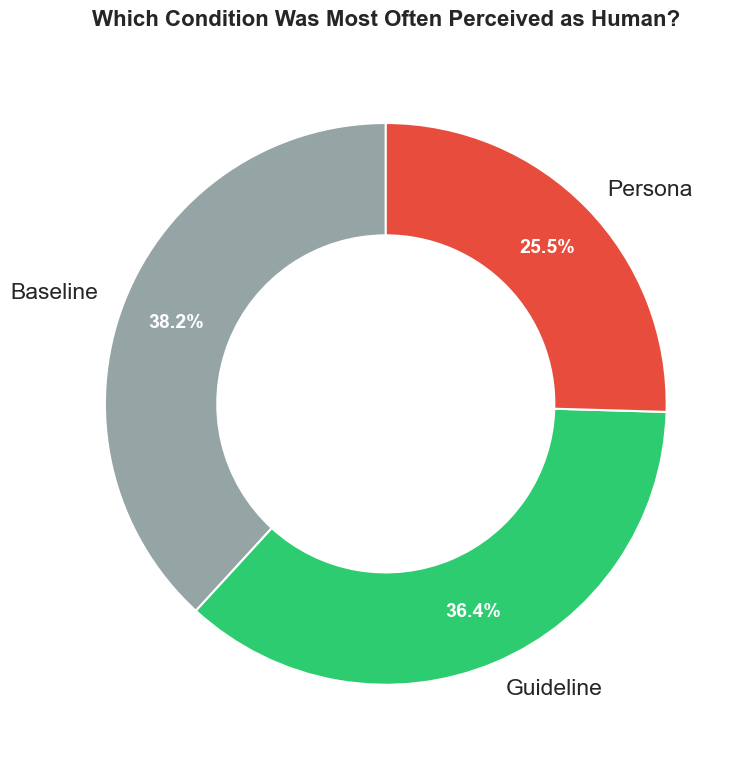

In [125]:
# Human Authorship Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

human_col = 'human_authorship_selected_condition'
human_counts = data[data[human_col].isin(['Baseline', 'Guideline', 'Persona'])][human_col].value_counts()

colors = [palette.get(x, '#333333') for x in human_counts.index]

wedges, texts, autotexts = ax.pie(human_counts, labels=human_counts.index, autopct='%1.1f%%', 
                                  startangle=90, colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'), pctdistance=0.80)

plt.setp(autotexts, size=14, weight="bold", color="white")
ax.set_title('Which Condition Was Most Often Perceived as Human?', pad=20, fontweight='bold', size=16)

plt.tight_layout()
plt.show()

### Does Participant Expertise Matter?
Do highly familiar readers prefer structural Guidelines more than novices?


In [126]:
print("\nParticipant Familiarity with Poetry:")
print(data.drop_duplicates('sessionId')['familiarity'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


Participant Familiarity with Poetry:
familiarity
very_familiar        66.7%
somewhat_familiar    22.2%
not_very_familiar    11.1%
Name: proportion, dtype: str


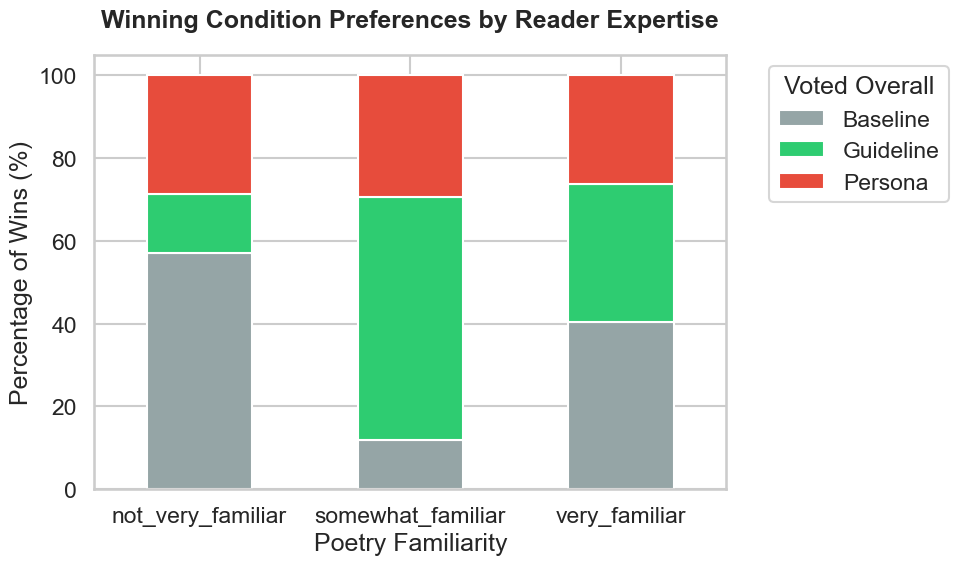

In [128]:
# Let's break down 'Stronger Overall' wins by the participant's self-reported familiarity
fam_wins = data[data['stronger_overall_selected_condition'].isin(['Baseline', 'Guideline', 'Persona'])]

fam_cross = pd.crosstab(fam_wins['familiarity'], fam_wins['stronger_overall_selected_condition'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
fam_cross.plot(kind='bar', stacked=True, color=[palette[c] for c in fam_cross.columns], ax=ax)

ax.set_title('Winning Condition Preferences by Reader Expertise', pad=20, fontweight='bold')
ax.set_ylabel('Percentage of Wins (%)')
ax.set_xlabel('Poetry Familiarity')
plt.xticks(rotation=0)
plt.legend(title='Voted Overall', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [129]:
display(fam_cross.round(1).astype(str) + '%')

stronger_overall_selected_condition,Baseline,Guideline,Persona
familiarity,,,
not_very_familiar,57.1%,14.3%,28.6%
somewhat_familiar,11.8%,58.8%,29.4%
very_familiar,40.5%,33.3%,26.2%


### Metric Correlation Heatmap
If a poem wins 'Emotional Impact', does it also win 'Like / Endorse'?


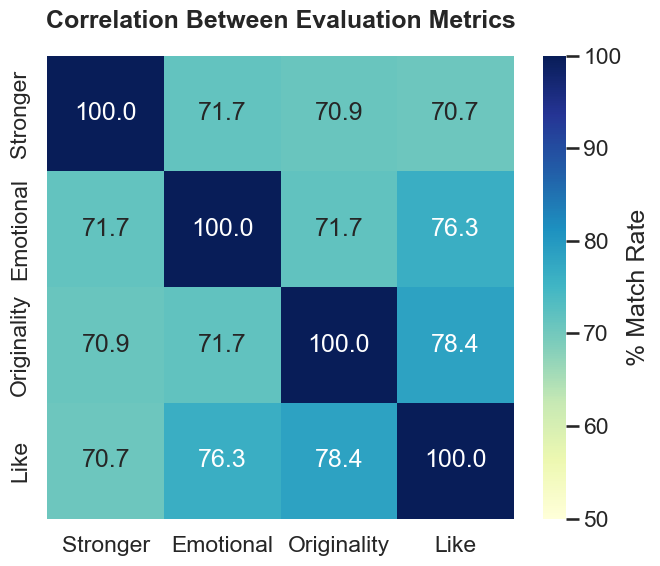

In [130]:
# Let's compute how often the SAME poem won different categories in the same comparison
cats = ['stronger_overall', 'emotional_impact', 'originality', 'like']
labels = ['Stronger', 'Emotional', 'Originality', 'Like']
corr_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)

for i, cat1 in enumerate(cats):
    for j, cat2 in enumerate(cats):
        col1 = f"{cat1}_selected_poem_id"
        col2 = f"{cat2}_selected_poem_id"
        
        # We only look at rows where an explicit poem was chosen for BOTH questions (A or B)
        # Exclude TIE, BOTH, NEITHER, etc.
        valid_mask = data[col1].str.contains('-') & data[col2].str.contains('-')
        
        if valid_mask.sum() > 0:
            # Percentage of times they picked the exact same poem for both categories
            match_pct = (data.loc[valid_mask, col1] == data.loc[valid_mask, col2]).mean() * 100
            corr_matrix.iloc[i, j] = match_pct

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap="YlGnBu", vmin=50, vmax=100, 
            cbar_kws={'label': '% Match Rate'}, ax=ax)

ax.set_title('Correlation Between Evaluation Metrics', pad=20, fontweight='bold')
plt.tight_layout()
plt.show()


## Synthetic Analysis
Addressing the core questions of your research study directly for your presentation slides.


### Uncertainty Analysis
How often do participants choose TIE / BOTH / NOT SURE? Which comparisons lead to the most uncertainty? (Insight: When do differences between prompts disappear?)


In [131]:
# Calculate uncertainty percentages
total = len(data)
print("--- Overall Uncertainty Rates (% of 'TIE', 'BOTH', 'NEITHER', 'NOT_SURE') ---")
for col in ['stronger_overall', 'emotional_impact', 'originality', 'like', 'human_authorship']:
    mask = ~data[f'{col}_selected_condition'].isin(['Baseline', 'Guideline', 'Persona'])
    pct = (mask.sum() / total) * 100
    print(f"{col.replace('_', ' ').title():>25}: {pct:.1f}%")

print("\n--- Which pairwise comparison causes the most 'Stronger Overall' Ties? ---")
tie_rates = data[data['stronger_overall_selected_condition'] == 'TIE'].groupby('comparison_type').size()
comp_totals = data.groupby('comparison_type').size()
display((tie_rates / comp_totals * 100).fillna(0).round(1).astype(str) + '%')

print("\n--- Which pairwise comparison causes the most 'Human Authorship' Uncertainty? ---")
human_mask = ~data['human_authorship_selected_condition'].isin(['Baseline', 'Guideline', 'Persona'])
human_unc_rates = data[human_mask].groupby('comparison_type').size()
display((human_unc_rates / comp_totals * 100).fillna(0).round(1).astype(str) + '%')


--- Overall Uncertainty Rates (% of 'TIE', 'BOTH', 'NEITHER', 'NOT_SURE') ---
         Stronger Overall: 18.5%
         Emotional Impact: 19.8%
              Originality: 27.2%
                     Like: 19.8%
         Human Authorship: 32.1%

--- Which pairwise comparison causes the most 'Stronger Overall' Ties? ---


comparison_type
Baseline_vs_Guideline    13.0%
Baseline_vs_Persona      23.1%
Guideline_vs_Persona     18.8%
dtype: str


--- Which pairwise comparison causes the most 'Human Authorship' Uncertainty? ---


comparison_type
Baseline_vs_Guideline    34.8%
Baseline_vs_Persona      30.8%
Guideline_vs_Persona     31.2%
dtype: str

### Are 'Better' Poems Perceived as Human?
Cross-tabulating Stronger/Liked vs Human Authorship. P(Human | Condition Wins)


P(Condition is perceived as Human | Condition won 'Stronger Overall')


human_authorship_selected_condition,Baseline,Guideline,Persona
stronger_overall_selected_condition,,,
Baseline,72.7%,9.1%,18.2%
Guideline,12.5%,68.8%,18.8%
Persona,25.0%,25.0%,50.0%


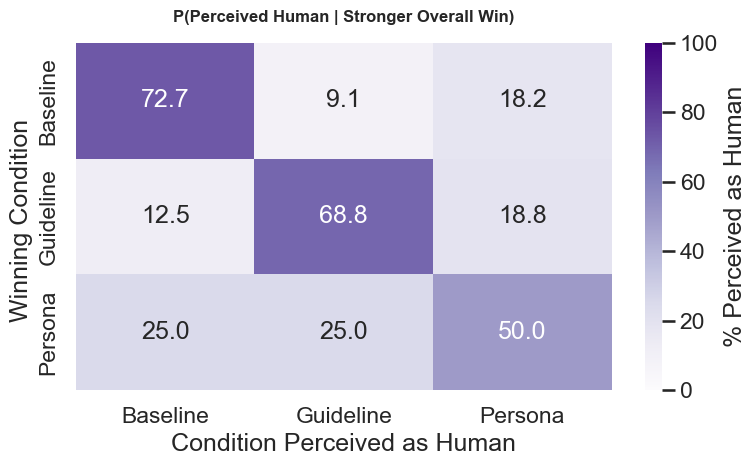

In [133]:
# When a specific condition wins 'Stronger Overall', what is the probability it is also perceived as 'Human'?
# Look only at rows where 'stronger' was an explicit choice (not Tie) and 'human' was an explicit choice
valid_mask = data['stronger_overall_selected_condition'].isin(['Baseline', 'Guideline', 'Persona']) &              data['human_authorship_selected_condition'].isin(['Baseline', 'Guideline', 'Persona'])

subset = data[valid_mask]
crosstab = pd.crosstab(subset['stronger_overall_selected_condition'], subset['human_authorship_selected_condition'], normalize='index') * 100

print("P(Condition is perceived as Human | Condition won 'Stronger Overall')")
display(crosstab.round(1).astype(str) + '%')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(crosstab, annot=True, fmt=".1f", cmap="Purples", vmin=0, vmax=100, cbar_kws={'label': '% Perceived as Human'})
ax.set_title("P(Perceived Human | Stronger Overall Win)", pad=15, fontweight='bold', fontsize=12)
ax.set_ylabel("Winning Condition ")
ax.set_xlabel("Condition Perceived as Human")
plt.tight_layout()
plt.show()
